In [1]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
265 51


In [2]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
ron_train = [float(c['Meas RON']) for c in compounds_train]
mon_train = [float(c['Meas MON']) for c in compounds_train]
targets_train = [[ron_train[i], mon_train[i]] for i in range(len(mon_train))]

smiles_test = [c[' SMILES'] for c in compounds_test]
ron_test = [float(c['Meas RON']) for c in compounds_test]
mon_test = [float(c['Meas MON']) for c in compounds_test]
targets_test = [[ron_test[i], mon_test[i]] for i in range(len(mon_test))]

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [4]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
# Retain descriptors such that 99.9% of descriptor-property correlation is retained
desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.999, n_estimators=64, n_jobs=8)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
print(dataset_train.desc_names[:10])
print(desc_imp[:10])

torch.Size([265, 1026]) torch.Size([51, 1026])
torch.Size([265, 787]) torch.Size([51, 787])
['SssCH2', 'ChiA_B(s)', 'GATS2m', 'ON1V', 'SpMaxA_EA(bo)', 'Eta_L_A', 'TI2_L', 'SpMin1_Bh(s)', 'BIC1', 'HVcpx']
[0.24659550429612498, 0.16232659552732878, 0.13127445098320037, 0.019521094214192864, 0.018426266777864977, 0.01698453357694494, 0.01383620022703188, 0.012272219667632648, 0.01043836844699477, 0.010259004614786672]


In [9]:
desc_1 = [float(d[0]) for d in dataset_train.desc_vals]
desc_1_test = [float(d[0]) for d in dataset_test.desc_vals]
desc_1.extend(desc_1_test)
desc_1_name = dataset_train.desc_names[0]

desc_2 = [float(d[1]) for d in dataset_train.desc_vals]
desc_2_test = [float(d[1]) for d in dataset_test.desc_vals]
desc_2.extend(desc_2_test)
desc_2_name = dataset_train.desc_names[1]

desc_3 = [float(d[2]) for d in dataset_train.desc_vals]
desc_3_test = [float(d[2]) for d in dataset_test.desc_vals]
desc_3.extend(desc_3_test)
desc_3_name = dataset_train.desc_names[2]

ron = ron_train[:]
ron.extend(ron_test)
mon = mon_train[:]
mon.extend(mon_test)

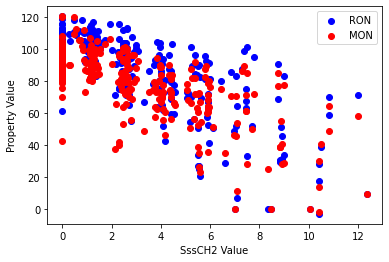

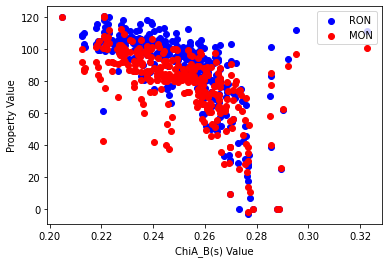

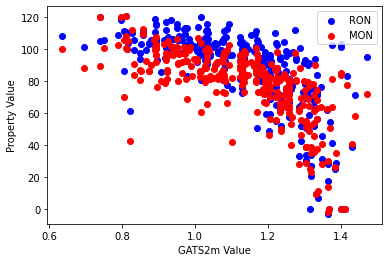

In [11]:
from matplotlib import pyplot as plt

plt.clf()
plt.xlabel(f'{desc_1_name} Value')
plt.ylabel('Property Value')
plt.scatter(desc_1, ron, color='blue', label='RON')
plt.scatter(desc_1, mon, color='red', label='MON')
plt.legend(loc='lower left')
plt.show()

plt.clf()
plt.xlabel(f'{desc_2_name} Value')
plt.ylabel('Property Value')
plt.scatter(desc_2, ron, color='blue', label='RON')
plt.scatter(desc_2, mon, color='red', label='MON')
plt.legend(loc='lower left')
plt.show()

plt.clf()
plt.xlabel(f'{desc_3_name} Value')
plt.ylabel('Property Value')
plt.scatter(desc_3, ron, color='blue', label='RON')
plt.scatter(desc_3, mon, color='red', label='MON')
plt.legend(loc='lower left')
plt.show()